# Proyecto completo de Data Science: Predicción de precios de casas

Este notebook fue diseñado para servir como **flujo completo de trabajo** de un proyecto de Data Science aplicado a bienes raíces.

## Objetivos del notebook
- Cargar y explorar el dataset.
- Realizar un **EDA** estadístico y visual.
- Limpiar los datos.
- Crear variables derivadas útiles.
- Entrenar modelos de Machine Learning.
- Evaluar el rendimiento.
- Exportar el mejor modelo para usarlo en una API.

## Nota
Todo el código está escrito con comentarios explicativos para que puedas estudiarlo, modificarlo y reutilizarlo.


## 1. Importación de librerías

En esta sección importamos todas las librerías necesarias para:
- manipular datos
- visualizar información
- entrenar modelos
- evaluar resultados
- exportar el modelo final


In [82]:
# Importamos la librería os para trabajar con rutas del sistema.
import os

# Importamos warnings para ocultar advertencias no críticas y hacer la salida más limpia.
import warnings

# Importamos numpy para operaciones numéricas y arreglos.
import numpy as np

# Importamos pandas para cargar, limpiar y transformar la data.
import pandas as pd

# Importamos matplotlib para crear gráficos.
import matplotlib.pyplot as plt

# Importamos seaborn para hacer visualizaciones estadísticas más cómodas.
import seaborn as sns

# Importamos joblib para guardar el modelo entrenado en disco.
import joblib

# Importamos métricas para evaluar modelos de regresión.
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Importamos la función para dividir el dataset en entrenamiento y prueba.
from sklearn.model_selection import train_test_split

# Importamos herramientas para el preprocesamiento.
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Importamos distintos modelos de regresión para compararlos.
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor

# Configuramos pandas para mostrar más columnas cuando inspeccionemos el dataset.
pd.set_option("display.max_columns", 100)

# Configuramos el estilo de seaborn para que las gráficas se vean mejor.
sns.set_theme(style="whitegrid")

# Ocultamos advertencias molestas que no afectan al flujo principal.
warnings.filterwarnings("ignore")

# Mostramos un mensaje de confirmación.
print("Librerías importadas correctamente.")


Librerías importadas correctamente.


## 2. Definición de rutas

Aquí definimos la ruta del dataset original y las carpetas donde guardaremos:
- la data procesada
- las figuras del EDA
- el modelo entrenado
- las métricas del experimento


In [83]:
# Definimos la ruta base donde se está ejecutando este notebook.
BASE_DIR = os.getcwd()

# Creamos una lista de rutas posibles para encontrar el dataset, dependiendo de dónde abras el notebook.
possible_paths = [
    os.path.join(BASE_DIR, "USA_Housing_Dataset.csv"),
    os.path.join(BASE_DIR, "datascience", "data", "raw", "USA Housing Dataset.csv"),
    os.path.join(BASE_DIR, "..", "data", "raw", "USA Housing Dataset.csv"),
    "/mnt/data/USA Housing Dataset.csv"
]

# Inicializamos la variable del dataset en None.
data_path = None

# Recorremos las rutas posibles hasta encontrar una que exista.
for path in possible_paths:
    if os.path.exists(path):
        data_path = path
        break

# Validamos que el archivo exista realmente.
if data_path is None:
    raise FileNotFoundError("No se encontró el archivo 'USA Housing Dataset.csv'.")

# Definimos una carpeta de salida para guardar artefactos del notebook.
output_dir = os.path.join(BASE_DIR, "notebook_outputs")

# Definimos una carpeta específica para las figuras.
figures_dir = os.path.join(output_dir, "figures")

# Definimos una carpeta para guardar modelos.
models_dir = os.path.join(output_dir, "models")

# Creamos las carpetas si no existen.
os.makedirs(figures_dir, exist_ok=True)
os.makedirs(models_dir, exist_ok=True)

# Mostramos la ruta encontrada del dataset.
print("Dataset encontrado en:", data_path)

# Mostramos la carpeta donde se guardarán salidas.
print("Carpeta de salida:", output_dir)


Dataset encontrado en: /Users/home/Library/Mobile Documents/com~apple~CloudDocs/Coding Academy/Curso/DataSciencs/Curso3hr/ProyectoDataScienses1/datascience/USA_Housing_Dataset.csv
Carpeta de salida: /Users/home/Library/Mobile Documents/com~apple~CloudDocs/Coding Academy/Curso/DataSciencs/Curso3hr/ProyectoDataScienses1/datascience/notebook_outputs


## 3. Carga inicial de datos

Ahora cargamos el dataset y revisamos las primeras filas para entender su estructura.


In [84]:
# Cargamos el dataset en un DataFrame de pandas.
df = pd.read_csv(data_path)

# Mostramos las primeras filas para inspección rápida.
df.head()


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-09 00:00:00,376000.0,3.0,2.00,1340,1384,3.0,0,0,3,1340,0,2008,0,9245-9249 Fremont Ave N,Seattle,WA 98103,USA
1,2014-05-09 00:00:00,800000.0,4.0,3.25,3540,159430,2.0,0,0,3,3540,0,2007,0,33001 NE 24th St,Carnation,WA 98014,USA
2,2014-05-09 00:00:00,2238888.0,5.0,6.50,7270,130017,2.0,0,0,3,6420,850,2010,0,7070 270th Pl SE,Issaquah,WA 98029,USA
3,2014-05-09 00:00:00,324000.0,3.0,2.25,998,904,2.0,0,0,3,798,200,2007,0,820 NW 95th St,Seattle,WA 98117,USA
4,2014-05-10 00:00:00,549900.0,5.0,2.75,3060,7015,1.0,0,0,5,1600,1460,1979,0,10834 31st Ave SW,Seattle,WA 98146,USA


## 4. Revisión general del dataset

En esta parte respondemos preguntas básicas:
- ¿cuántas filas y columnas hay?
- ¿qué tipos de datos existen?
- ¿hay valores nulos?
- ¿cómo se llaman las columnas?


In [85]:
# Mostramos la forma del dataset: filas y columnas.
print("Dimensiones del dataset:", df.shape)

# Mostramos los nombres de las columnas.
print("\nColumnas del dataset:")
print(df.columns.tolist())

# Mostramos información general del DataFrame.
print("\nInformación general:")
print(df.info())

# Mostramos cuántos nulos hay por columna.
print("\nValores nulos por columna:")
print(df.isnull().sum())


Dimensiones del dataset: (4140, 18)

Columnas del dataset:
['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city', 'statezip', 'country']

Información general:
<class 'pandas.DataFrame'>
RangeIndex: 4140 entries, 0 to 4139
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4140 non-null   str    
 1   price          4140 non-null   float64
 2   bedrooms       4140 non-null   float64
 3   bathrooms      4140 non-null   float64
 4   sqft_living    4140 non-null   int64  
 5   sqft_lot       4140 non-null   int64  
 6   floors         4140 non-null   float64
 7   waterfront     4140 non-null   int64  
 8   view           4140 non-null   int64  
 9   condition      4140 non-null   int64  
 10  sqft_above     4140 non-null   int64  
 11  sqft_basement  4140 non-null   

## 5. Estadística descriptiva

Aquí generamos un resumen estadístico para observar:
- medias
- desviaciones
- mínimos y máximos
- percentiles


In [86]:
# Generamos la estadística descriptiva de todas las columnas numéricas.
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
date,4140,68,2014-06-23 00:00:00,142,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,4140.0,NaN,NaN,NaN,553062.877289,583686.452245,0.0,320000.0,460000.0,659125.0,26590000.0
bedrooms,4140.0,NaN,NaN,NaN,3.400483,0.903939,0.0,3.0,3.0,4.0,8.0
bathrooms,4140.0,NaN,NaN,NaN,2.163043,0.784733,0.0,1.75,2.25,2.5,6.75
sqft_living,4140.0,NaN,NaN,NaN,2143.638889,957.481621,370.0,1470.0,1980.0,2620.0,10040.0
sqft_lot,4140.0,NaN,NaN,NaN,14697.638164,35876.838123,638.0,5000.0,7676.0,11000.0,1074218.0
floors,4140.0,NaN,NaN,NaN,1.51413,0.534941,1.0,1.0,1.5,2.0,3.5
waterfront,4140.0,NaN,NaN,NaN,0.007488,0.086219,0.0,0.0,0.0,0.0,1.0
view,4140.0,NaN,NaN,NaN,0.246618,0.790619,0.0,0.0,0.0,0.0,4.0
condition,4140.0,NaN,NaN,NaN,3.452415,0.678533,1.0,3.0,3.0,4.0,5.0


## 6. Inspección de la variable objetivo

La variable objetivo del problema es `price`.
Vamos a observar:
- distribución
- sesgo
- presencia de valores extremos o anómalos


In [87]:
# Mostramos estadística básica de la columna price.
print(df["price"].describe())

# Contamos cuántas casas tienen precio igual a cero.
zero_prices = (df["price"] == 0).sum()

# Mostramos ese conteo.
print("\nCasas con precio igual a 0:", zero_prices)


count    4.140000e+03
mean     5.530629e+05
std      5.836865e+05
min      0.000000e+00
25%      3.200000e+05
50%      4.600000e+05
75%      6.591250e+05
max      2.659000e+07
Name: price, dtype: float64

Casas con precio igual a 0: 49


## 7. EDA visual general

A continuación generamos visualizaciones importantes para entender la data visualmente.


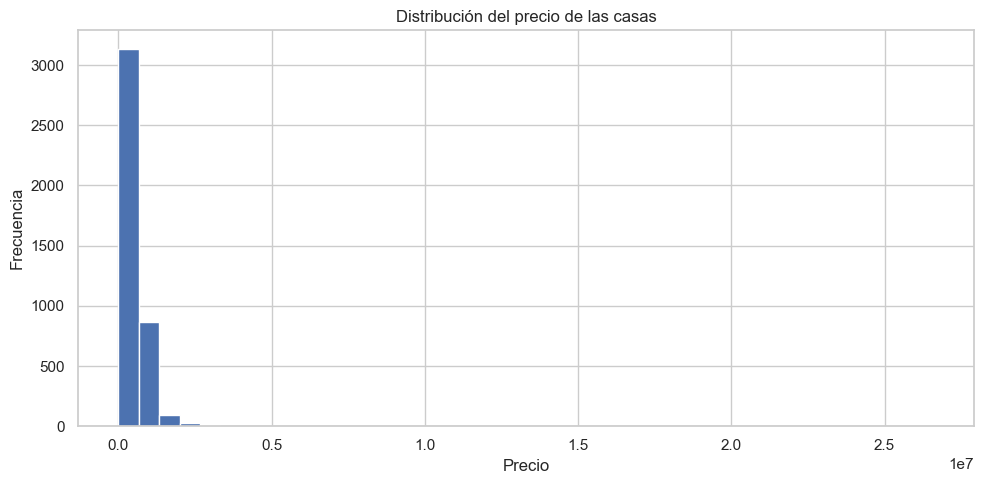

In [88]:
# Creamos una figura para ver la distribución del precio.
plt.figure(figsize=(10, 5))

# Graficamos el histograma del precio.
plt.hist(df["price"], bins=40)

# Colocamos un título claro.
plt.title("Distribución del precio de las casas")

# Colocamos el nombre del eje X.
plt.xlabel("Precio")

# Colocamos el nombre del eje Y.
plt.ylabel("Frecuencia")

# Ajustamos el diseño para evitar cortes.
plt.tight_layout()

# Guardamos la figura en disco.
plt.savefig(os.path.join(figures_dir, "01_hist_price.png"))

# Mostramos la gráfica.
plt.show()


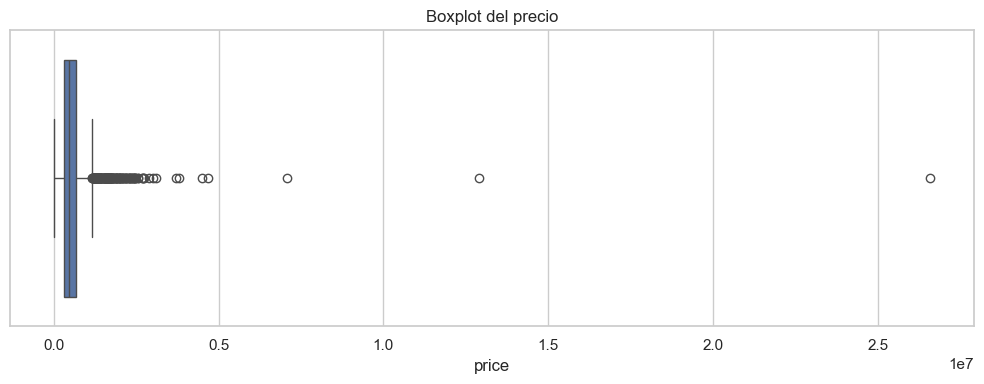

In [89]:
# Creamos una figura para observar outliers en la variable objetivo.
plt.figure(figsize=(10, 4))

# Dibujamos un boxplot horizontal para el precio.
sns.boxplot(x=df["price"])

# Colocamos un título.
plt.title("Boxplot del precio")

# Ajustamos diseño.
plt.tight_layout()

# Guardamos la figura.
plt.savefig(os.path.join(figures_dir, "02_boxplot_price.png"))

# Mostramos la figura.
plt.show()


## 8. Visualización de variables numéricas relevantes

Seleccionamos algunas variables importantes del negocio inmobiliario para entender su comportamiento.


In [90]:
# Definimos una lista de columnas numéricas relevantes.
numeric_cols = [
    "price", "bedrooms", "bathrooms", "sqft_living",
    "sqft_lot", "floors", "waterfront", "view",
    "condition", "sqft_above", "sqft_basement",
    "yr_built", "yr_renovated"
]

# Filtramos solo aquellas columnas que realmente existen en el dataset.
numeric_cols = [col for col in numeric_cols if col in df.columns]

# Mostramos la lista final.
print("Columnas numéricas seleccionadas:", numeric_cols)


Columnas numéricas seleccionadas: ['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated']


### Nota
Un `pairplot` completo puede ser pesado.  
Por eso usaremos histogramas individuales y una matriz de correlación, que suelen ser más útiles y más ligeras.


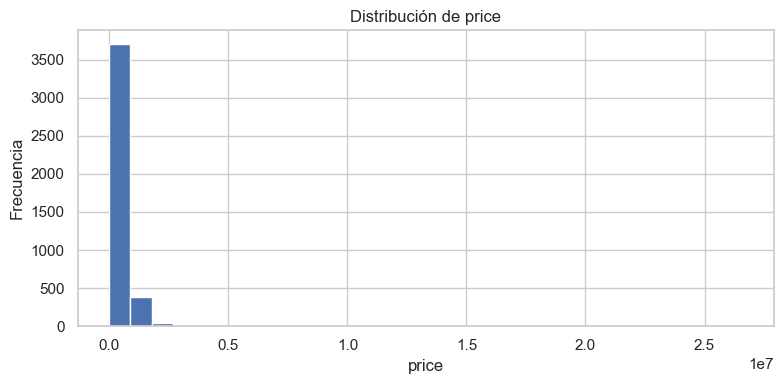

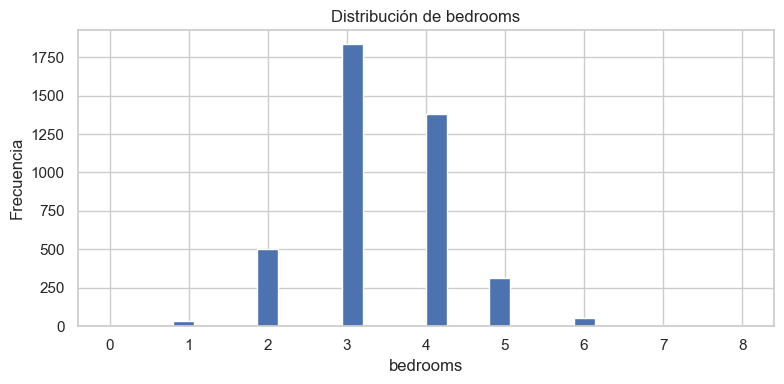

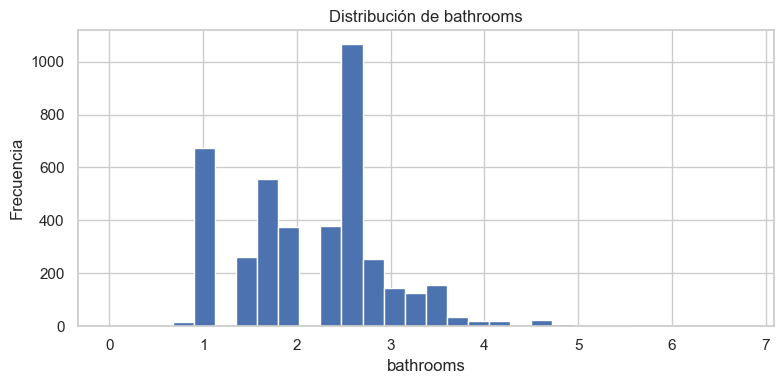

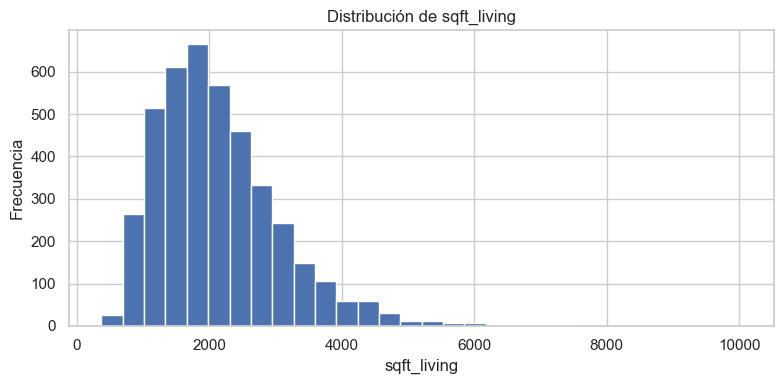

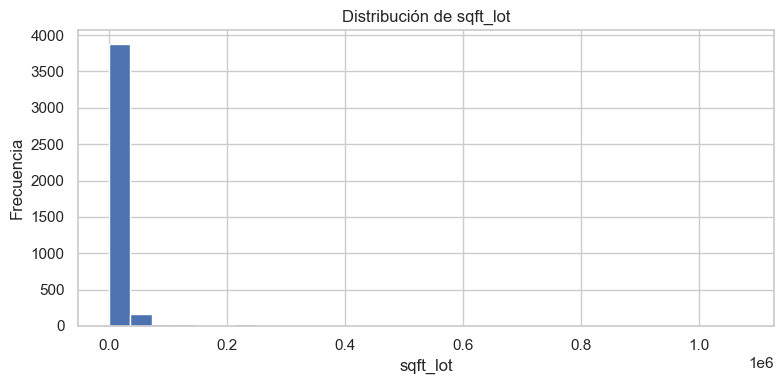

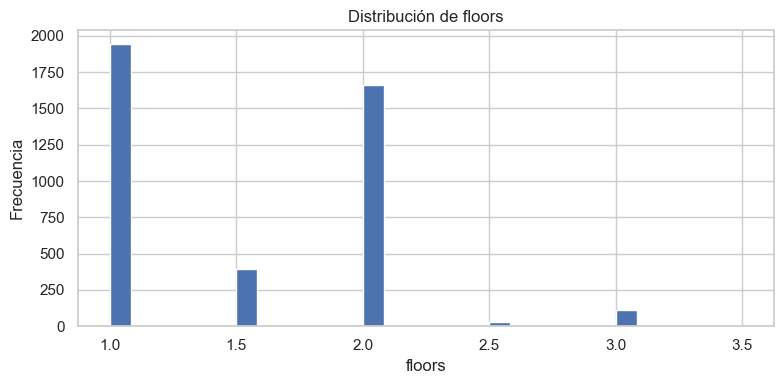

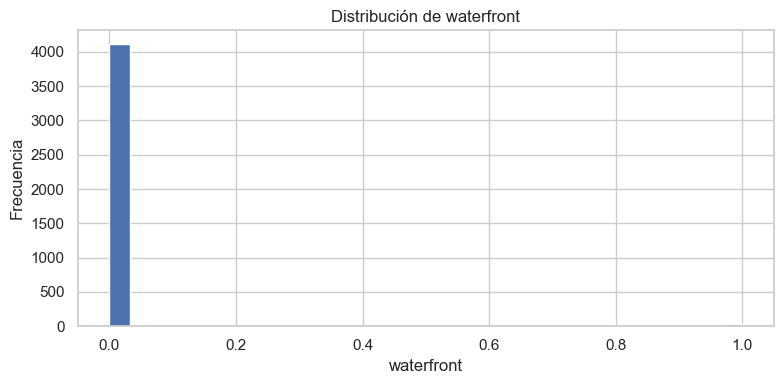

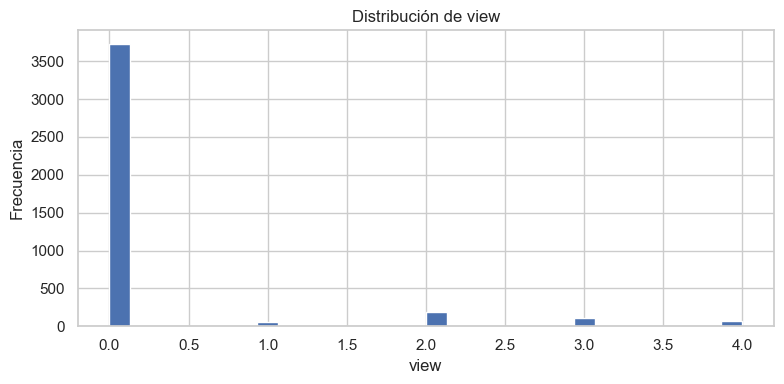

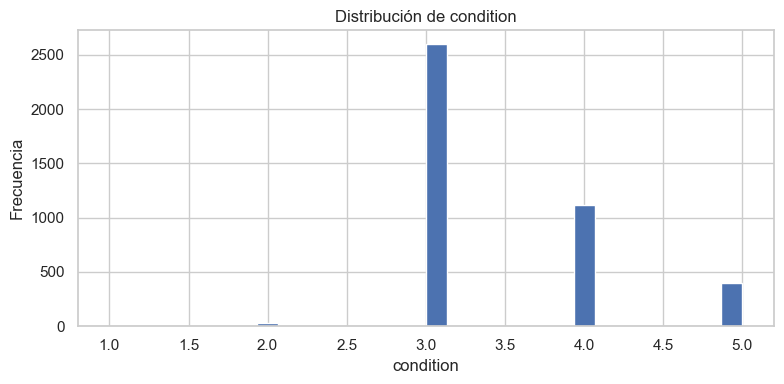

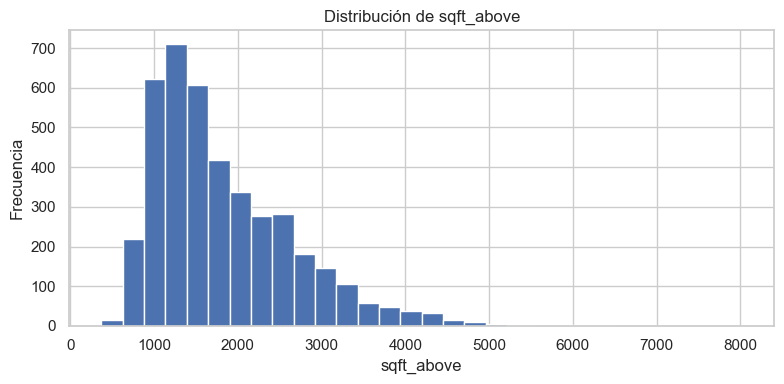

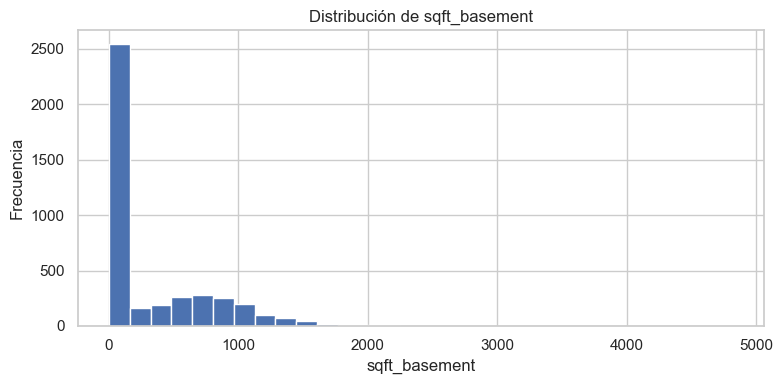

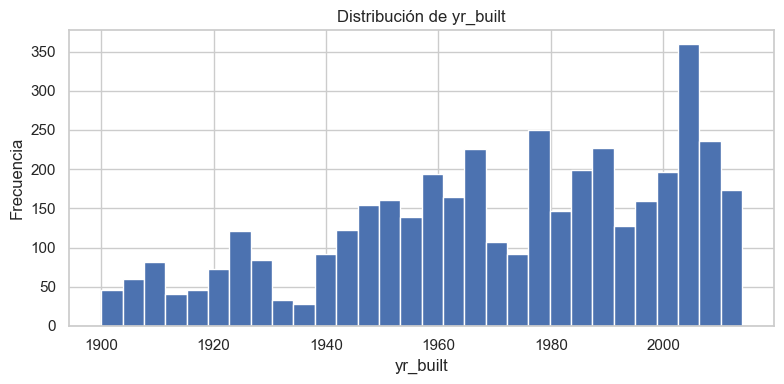

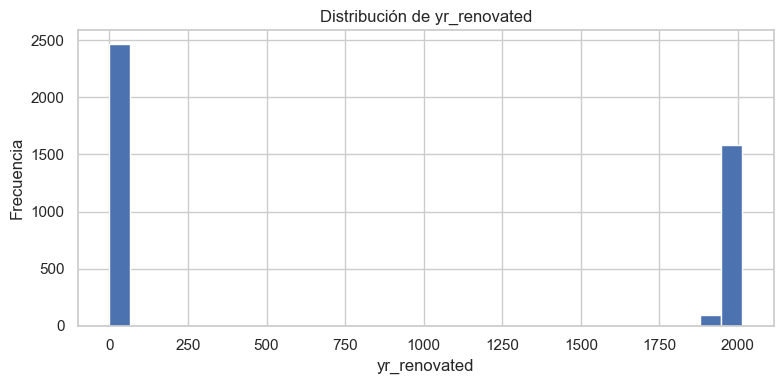

In [91]:
# Recorremos cada columna numérica seleccionada.
for col in numeric_cols:
    # Creamos una figura individual para cada variable.
    plt.figure(figsize=(8, 4))

    # Dibujamos un histograma simple.
    plt.hist(df[col].dropna(), bins=30)

    # Agregamos título.
    plt.title(f"Distribución de {col}")

    # Etiquetamos el eje X.
    plt.xlabel(col)

    # Etiquetamos el eje Y.
    plt.ylabel("Frecuencia")

    # Ajustamos el diseño.
    plt.tight_layout()

    # Guardamos la figura con un nombre automático.
    plt.savefig(os.path.join(figures_dir, f"hist_{col}.png"))

    # Mostramos la gráfica.
    plt.show()


## 9. Correlación entre variables numéricas

La matriz de correlación nos permite detectar:
- variables muy relacionadas con `price`
- redundancias entre predictores
- relaciones lineales fuertes


In [92]:
# Calculamos la matriz de correlación solo para variables numéricas.
corr = df[numeric_cols].corr(numeric_only=True)

# Mostramos las correlaciones con la variable price ordenadas de mayor a menor.
if "price" in corr.columns:
    print(corr["price"].sort_values(ascending=False))


price            1.000000
sqft_living      0.418528
sqft_above       0.355214
bathrooms        0.317785
view             0.217553
sqft_basement    0.204066
bedrooms         0.188765
floors           0.143180
waterfront       0.131401
sqft_lot         0.045964
condition        0.030327
yr_built         0.027067
yr_renovated    -0.028272
Name: price, dtype: float64


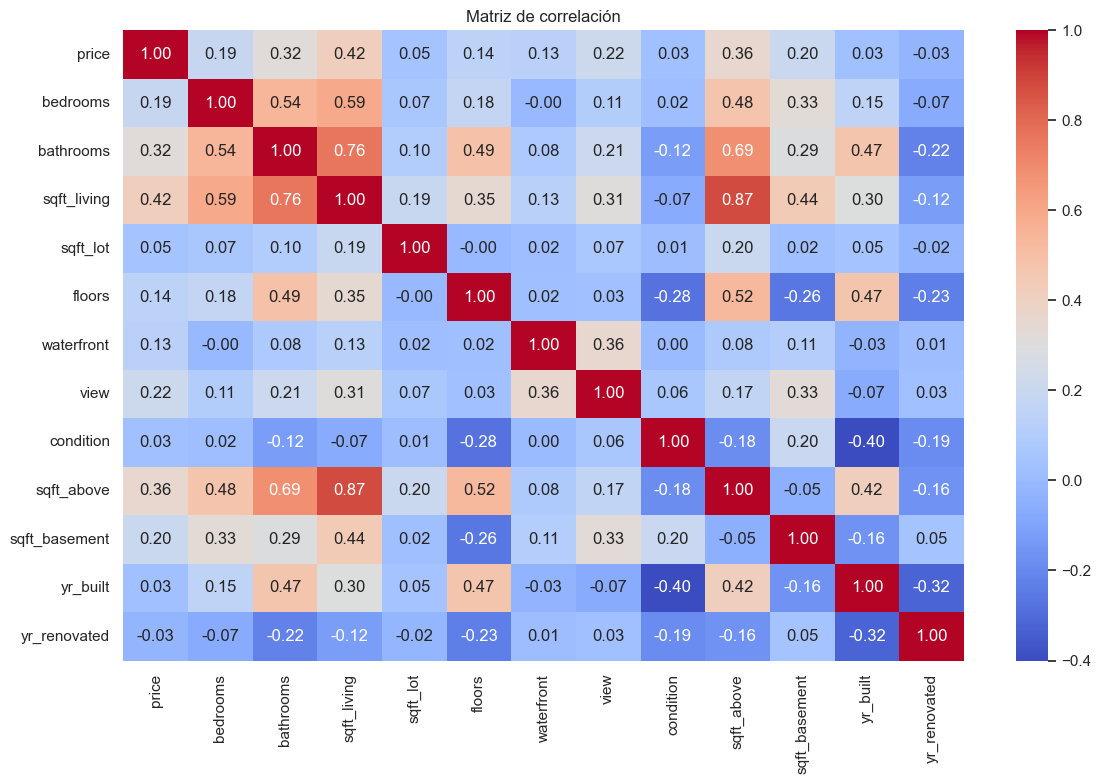

In [93]:
# Creamos una figura amplia para el mapa de calor.
plt.figure(figsize=(12, 8))

# Dibujamos el heatmap de correlaciones.
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")

# Colocamos título.
plt.title("Matriz de correlación")

# Ajustamos el diseño.
plt.tight_layout()

# Guardamos la imagen.
plt.savefig(os.path.join(figures_dir, "03_heatmap_correlations.png"))

# Mostramos la gráfica.
plt.show()


## 10. Análisis de variables categóricas

Revisamos principalmente:
- `city`
- `statezip`
- `country`

porque suelen tener relevancia geográfica para el precio.


In [94]:
# Definimos posibles columnas categóricas de interés.
categorical_candidates = ["city", "statezip", "country", "street"]

# Filtramos solo las que existan.
categorical_cols = [col for col in categorical_candidates if col in df.columns]

# Mostramos la lista final.
print("Columnas categóricas disponibles:", categorical_cols)

# Recorremos las columnas categóricas y mostramos la cantidad de valores únicos.
for col in categorical_cols:
    print(f"\nColumna: {col}")
    print("Valores únicos:", df[col].nunique())
    print(df[col].value_counts().head(10))


Columnas categóricas disponibles: ['city', 'statezip', 'country', 'street']

Columna: city
Valores únicos: 43
city
Seattle        1415
Renton          261
Bellevue        260
Redmond         209
Kent            167
Kirkland        166
Issaquah        162
Auburn          162
Sammamish       158
Federal Way     131
Name: count, dtype: int64

Columna: statezip
Valores únicos: 77
statezip
WA 98103    128
WA 98052    120
WA 98117    119
WA 98115    114
WA 98006    101
WA 98059     94
WA 98038     90
WA 98074     89
WA 98058     88
WA 98042     88
Name: count, dtype: int64

Columna: country
Valores únicos: 1
country
USA    4140
Name: count, dtype: int64

Columna: street
Valores únicos: 4079
street
2520 Mulberry Walk NE    4
2500 Mulberry Walk NE    3
820 NW 95th St           2
106 24th Ave E           2
9413 34th Ave SW         2
Indian Trail             2
8434 W Mercer Way        2
615 NW 92nd St           2
353 N 105th St           2
6520-6588 8th Ave NW     2
Name: count, dtype: int64


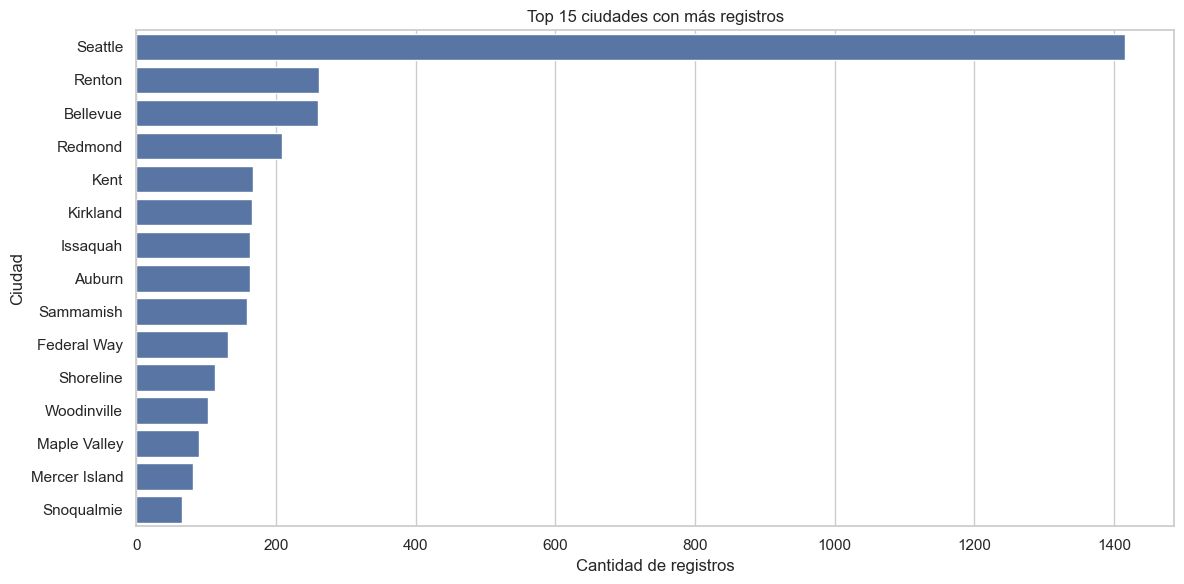

In [95]:
# Verificamos que la columna city exista.
if "city" in df.columns:
    # Obtenemos las 15 ciudades más frecuentes.
    top_cities = df["city"].value_counts().head(15)

    # Creamos la figura.
    plt.figure(figsize=(12, 6))

    # Dibujamos la gráfica de barras.
    sns.barplot(x=top_cities.values, y=top_cities.index)

    # Título de la visualización.
    plt.title("Top 15 ciudades con más registros")

    # Etiqueta del eje X.
    plt.xlabel("Cantidad de registros")

    # Etiqueta del eje Y.
    plt.ylabel("Ciudad")

    # Ajuste visual.
    plt.tight_layout()

    # Guardamos la figura.
    plt.savefig(os.path.join(figures_dir, "04_top_cities.png"))

    # Mostramos la gráfica.
    plt.show()


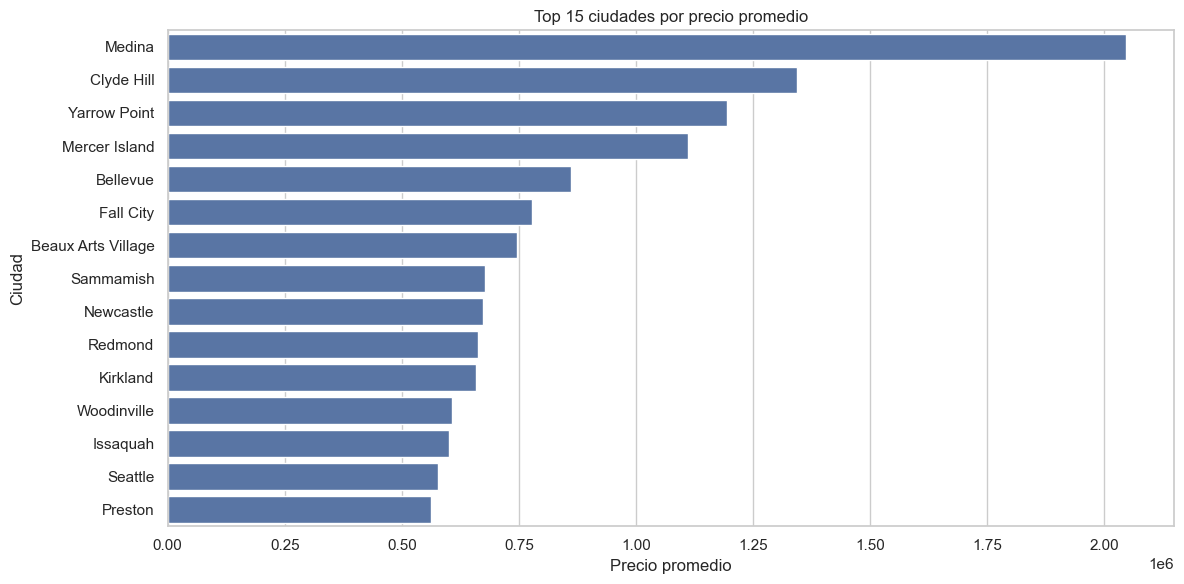

In [96]:
# Verificamos que la columna city exista.
if "city" in df.columns:
    # Calculamos el precio promedio por ciudad.
    avg_price_city = df.groupby("city")["price"].mean().sort_values(ascending=False).head(15)

    # Creamos una figura.
    plt.figure(figsize=(12, 6))

    # Dibujamos una barra horizontal.
    sns.barplot(x=avg_price_city.values, y=avg_price_city.index)

    # Definimos el título.
    plt.title("Top 15 ciudades por precio promedio")

    # Etiquetamos ejes.
    plt.xlabel("Precio promedio")
    plt.ylabel("Ciudad")

    # Ajustamos el diseño.
    plt.tight_layout()

    # Guardamos la figura.
    plt.savefig(os.path.join(figures_dir, "05_avg_price_city.png"))

    # Mostramos la gráfica.
    plt.show()


## 11. Limpieza de datos

En esta sección realizamos decisiones de limpieza razonables:
- eliminar precios cero
- convertir fechas
- eliminar columnas poco útiles o demasiado específicas


In [97]:
# Hacemos una copia del DataFrame original para no modificarlo directamente.
df_clean = df.copy()

# Eliminamos registros con precio igual a 0 porque distorsionan el modelo.
df_clean = df_clean[df_clean["price"] > 0].copy()

# Si existe la columna date, la convertimos a formato fecha.
if "date" in df_clean.columns:
    df_clean["date"] = pd.to_datetime(df_clean["date"], errors="coerce")

# Mostramos la nueva forma del dataset luego de quitar precios cero.
print("Dimensiones después de limpieza inicial:", df_clean.shape)


Dimensiones después de limpieza inicial: (4091, 18)


## 12. Feature Engineering

Creamos variables derivadas útiles para capturar mejor la lógica del negocio.


In [98]:
# Si existe la columna date, extraemos el año de venta.
if "date" in df_clean.columns:
    df_clean["sale_year"] = df_clean["date"].dt.year

# Si existe la columna date, extraemos el mes de venta.
if "date" in df_clean.columns:
    df_clean["sale_month"] = df_clean["date"].dt.month

# Si existe la columna yr_built, calculamos la edad de la casa respecto al año de venta cuando sea posible.
if "yr_built" in df_clean.columns and "sale_year" in df_clean.columns:
    df_clean["house_age"] = df_clean["sale_year"] - df_clean["yr_built"]
else:
    # Si no existe sale_year, usamos un año de referencia.
    if "yr_built" in df_clean.columns:
        df_clean["house_age"] = 2024 - df_clean["yr_built"]

# Si existe la columna yr_renovated, creamos una bandera binaria para saber si fue renovada.
if "yr_renovated" in df_clean.columns:
    df_clean["is_renovated"] = (df_clean["yr_renovated"] > 0).astype(int)

# Si existe la columna yr_renovated, calculamos años desde la renovación.
if "yr_renovated" in df_clean.columns and "sale_year" in df_clean.columns:
    df_clean["renovation_age"] = np.where(
        df_clean["yr_renovated"] > 0,
        df_clean["sale_year"] - df_clean["yr_renovated"],
        0
    )

# Si existen baños y habitaciones, calculamos una razón útil.
if "bathrooms" in df_clean.columns and "bedrooms" in df_clean.columns:
    df_clean["bath_bed_ratio"] = df_clean["bathrooms"] / df_clean["bedrooms"].replace(0, np.nan)

# Si existen varias superficies, calculamos un total utilizable.
if "sqft_living" in df_clean.columns and "sqft_basement" in df_clean.columns:
    df_clean["usable_space"] = df_clean["sqft_living"] + df_clean["sqft_basement"]

# Mostramos algunas filas para validar variables nuevas.
df_clean.head()


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country,sale_year,sale_month,house_age,is_renovated,renovation_age,bath_bed_ratio,usable_space
0,2014-05-09,376000.0,3.0,2.00,1340,1384,3.0,0,0,3,1340,0,2008,0,9245-9249 Fremont Ave N,Seattle,WA 98103,USA,2014,5,6,0,0,0.666667,1340
1,2014-05-09,800000.0,4.0,3.25,3540,159430,2.0,0,0,3,3540,0,2007,0,33001 NE 24th St,Carnation,WA 98014,USA,2014,5,7,0,0,0.812500,3540
2,2014-05-09,2238888.0,5.0,6.50,7270,130017,2.0,0,0,3,6420,850,2010,0,7070 270th Pl SE,Issaquah,WA 98029,USA,2014,5,4,0,0,1.300000,8120
3,2014-05-09,324000.0,3.0,2.25,998,904,2.0,0,0,3,798,200,2007,0,820 NW 95th St,Seattle,WA 98117,USA,2014,5,7,0,0,0.750000,1198
4,2014-05-10,549900.0,5.0,2.75,3060,7015,1.0,0,0,5,1600,1460,1979,0,10834 31st Ave SW,Seattle,WA 98146,USA,2014,5,35,0,0,0.550000,4520


## 13. Selección de variables esenciales para el formulario y el modelo

Para simplificar la futura interfaz, nos quedaremos con variables más fáciles de pedir al usuario.


In [99]:
# Definimos una lista base de variables esenciales.
candidate_features = [
    "sqft_living",
    "bedrooms",
    "bathrooms",
    "floors",
    "condition",
    "view",
    "yr_built",
    "city",
    # "house_age",
    # "is_renovated"
]

# Nos quedamos solo con las que realmente existen en el DataFrame limpio.
selected_features = [col for col in candidate_features if col in df_clean.columns]

# Mostramos las variables seleccionadas.
print("Variables seleccionadas para modelado simplificado:")
print(selected_features)


Variables seleccionadas para modelado simplificado:
['sqft_living', 'bedrooms', 'bathrooms', 'floors', 'condition', 'view', 'yr_built', 'city']


## 14. Preparación de datos para Machine Learning

Aquí separamos:
- variables predictoras (`X`)
- variable objetivo (`y`)


In [100]:
# Construimos la matriz de características.
X = df_clean[selected_features].copy()

# Definimos la variable objetivo.
y = df_clean["price"].copy()

# Mostramos la forma de X e y.
print("Forma de X:", X.shape)
print("Forma de y:", y.shape)


Forma de X: (4091, 8)
Forma de y: (4091,)


## 15. División en entrenamiento y prueba

Separamos la data para medir rendimiento en datos no vistos.


In [101]:
# Dividimos los datos en entrenamiento y prueba.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Mostramos tamaños resultantes.
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


X_train: (3272, 8)
X_test: (819, 8)
y_train: (3272,)
y_test: (819,)


## 16. Preprocesamiento

Aplicamos transformaciones distintas según el tipo de columna:
- numéricas
- categóricas


In [102]:
# Detectamos columnas numéricas a partir del conjunto de entrenamiento.
numeric_features = X_train.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()

# Detectamos columnas categóricas a partir del conjunto de entrenamiento.
categorical_features = X_train.select_dtypes(include=["object"]).columns.tolist()

# Mostramos ambas listas para validación.
print("Columnas numéricas:", numeric_features)
print("Columnas categóricas:", categorical_features)

# Definimos un pipeline para variables numéricas.
numeric_transformer = Pipeline(steps=[
    # Imputamos faltantes con la mediana.
    ("imputer", SimpleImputer(strategy="median")),

    # Escalamos las variables numéricas.
    ("scaler", StandardScaler())
])

# Definimos un pipeline para variables categóricas.
categorical_transformer = Pipeline(steps=[
    # Imputamos faltantes con la categoría más frecuente.
    ("imputer", SimpleImputer(strategy="most_frequent")),

    # Codificamos categóricas usando one-hot encoding.
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combinamos ambos transformadores en un solo preprocesador.
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# Mostramos mensaje de confirmación.
print("Preprocesador creado correctamente.")


Columnas numéricas: ['sqft_living', 'bedrooms', 'bathrooms', 'floors', 'condition', 'view', 'yr_built']
Columnas categóricas: ['city']
Preprocesador creado correctamente.


## 17. Definición y entrenamiento de varios modelos

Entrenaremos varios algoritmos para comparar resultados:
- Linear Regression
- Random Forest
- Extra Trees
- Gradient Boosting


In [103]:
# Creamos un diccionario con modelos candidatos.
models = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),
    "ExtraTrees": ExtraTreesRegressor(
        n_estimators=400,
        random_state=42,
        n_jobs=-1
    ),
    "GradientBoosting": GradientBoostingRegressor(
        random_state=42
    )
}

# Creamos una lista para guardar resultados.
results = []

# Creamos un diccionario para guardar los pipelines entrenados.
trained_pipelines = {}

# Recorremos cada modelo del diccionario.
for name, model in models.items():
    # Creamos el pipeline completo: preprocesador + modelo.
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    # Entrenamos el pipeline con los datos de entrenamiento.
    pipe.fit(X_train, y_train)

    # Generamos predicciones sobre el conjunto de prueba.
    preds = pipe.predict(X_test)

    # Calculamos el error absoluto medio.
    mae = mean_absolute_error(y_test, preds)

    # Calculamos la raíz del error cuadrático medio.
    rmse = mean_squared_error(y_test, preds) ** 0.5

    # Calculamos el coeficiente de determinación R2.
    r2 = r2_score(y_test, preds)

    # Guardamos resultados en una lista.
    results.append({
        "model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

    # Guardamos el pipeline entrenado en el diccionario.
    trained_pipelines[name] = pipe

    # Imprimimos el rendimiento del modelo actual.
    print(f"Modelo: {name}")
    print(f"  MAE : {mae:,.2f}")
    print(f"  RMSE: {rmse:,.2f}")
    print(f"  R2  : {r2:.4f}")
    print("-" * 50)


Modelo: LinearRegression
  MAE : 130,418.45
  RMSE: 248,954.56
  R2  : 0.6098
--------------------------------------------------
Modelo: RandomForest
  MAE : 130,220.44
  RMSE: 289,233.06
  R2  : 0.4733
--------------------------------------------------
Modelo: ExtraTrees
  MAE : 128,941.47
  RMSE: 305,019.10
  R2  : 0.4142
--------------------------------------------------
Modelo: GradientBoosting
  MAE : 140,328.33
  RMSE: 303,687.67
  R2  : 0.4193
--------------------------------------------------


## 18. Comparación de resultados

Transformamos los resultados en un DataFrame para compararlos mejor.


In [104]:
# Convertimos la lista de resultados en un DataFrame.
results_df = pd.DataFrame(results)

# Ordenamos por R2 de mayor a menor.
results_df = results_df.sort_values(by="R2", ascending=False).reset_index(drop=True)

# Mostramos la tabla comparativa.
results_df


,model,MAE,RMSE,R2
0,LinearRegression,130418.447315,248954.560290,0.609769
1,RandomForest,130220.441970,289233.057120,0.473283
2,GradientBoosting,140328.328010,303687.669999,0.419321
3,ExtraTrees,128941.468574,305019.098711,0.414219


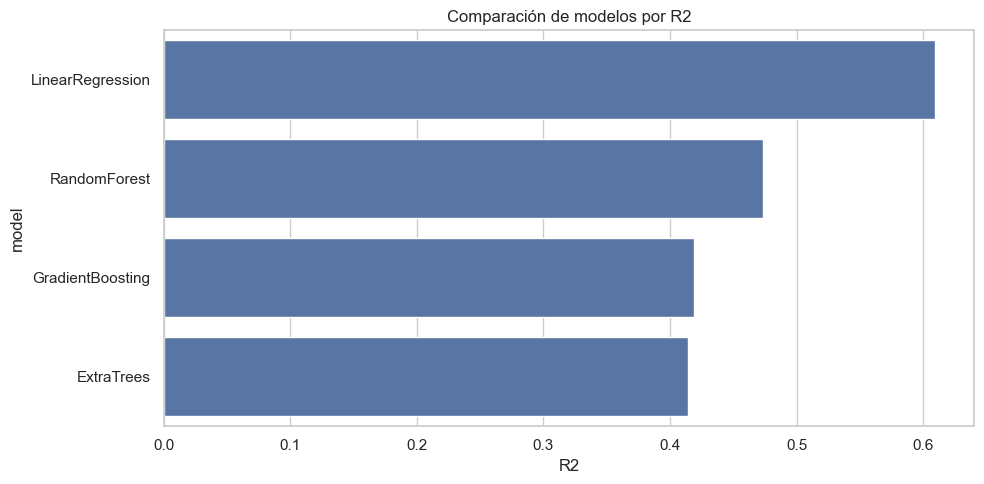

In [105]:
# Creamos una figura para comparar los R2 de los modelos.
plt.figure(figsize=(10, 5))

# Dibujamos una gráfica de barras.
sns.barplot(data=results_df, x="R2", y="model")

# Colocamos título.
plt.title("Comparación de modelos por R2")

# Ajustamos diseño.
plt.tight_layout()

# Guardamos la figura.
plt.savefig(os.path.join(figures_dir, "06_model_comparison_r2.png"))

# Mostramos la gráfica.
plt.show()


## 19. Selección y exportación del mejor modelo

Elegimos el modelo con mejor R² y lo guardamos para usarlo luego en la API.


In [106]:
# Obtenemos el nombre del mejor modelo según el DataFrame ordenado.
best_model_name = results_df.loc[0, "model"]

# Recuperamos el pipeline correspondiente.
best_pipeline = trained_pipelines[best_model_name]

# Definimos la ruta de salida del modelo.
best_model_path = os.path.join(models_dir, "model.joblib")

# Guardamos el pipeline completo en disco.
# joblib.dump(best_pipeline, best_model_path)
joblib.dump(best_pipeline, best_model_path)


# Mostramos confirmación.
print("Mejor modelo:", best_model_name)
print("Modelo exportado en:", best_model_path)


Mejor modelo: LinearRegression
Modelo exportado en: /Users/home/Library/Mobile Documents/com~apple~CloudDocs/Coding Academy/Curso/DataSciencs/Curso3hr/ProyectoDataScienses1/datascience/notebook_outputs/models/model.joblib


## 20. Importancia de variables del mejor modelo

Esta parte aplica solo si el modelo ganador permite extraer importancias.


In [107]:
# Verificamos si el mejor modelo tiene atributo feature_importances_.
inner_model = best_pipeline.named_steps["model"]

# Intentamos extraer nombres transformados del preprocesador.
feature_names = []

# Obtenemos el preprocesador interno.
inner_preprocessor = best_pipeline.named_steps["preprocessor"]

# Si existen columnas numéricas, las agregamos.
if len(numeric_features) > 0:
    feature_names.extend(numeric_features)

# Si existen columnas categóricas, recuperamos nombres transformados.
if len(categorical_features) > 0:
    cat_encoder = inner_preprocessor.named_transformers_["cat"].named_steps["onehot"]
    cat_names = cat_encoder.get_feature_names_out(categorical_features).tolist()
    feature_names.extend(cat_names)

# Si el modelo tiene importancias, las mostramos.
if hasattr(inner_model, "feature_importances_"):
    # Construimos un DataFrame con importancias.
    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": inner_model.feature_importances_
    }).sort_values(by="importance", ascending=False).head(20)

    # Mostramos tabla.
    display(importance_df)

    # Creamos una figura.
    plt.figure(figsize=(10, 6))

    # Graficamos las 20 variables más importantes.
    sns.barplot(data=importance_df, x="importance", y="feature")

    # Colocamos título.
    plt.title("Top 20 variables más importantes")

    # Ajustamos diseño.
    plt.tight_layout()

    # Guardamos la imagen.
    plt.savefig(os.path.join(figures_dir, "07_feature_importance.png"))

    # Mostramos la gráfica.
    plt.show()
else:
    print("El mejor modelo no expone feature_importances_.")


El mejor modelo no expone feature_importances_.


## 21. Ejemplo de predicción manual

Aquí construimos un ejemplo compatible con la idea del formulario simplificado.


In [108]:
# Creamos un ejemplo de entrada en forma de DataFrame.
sample = pd.DataFrame([{
    "sqft_living": 2500,
    "bedrooms": 3,
    "bathrooms": 2.5,
    "floors": 2,
    "condition": 4,
    "view": 3,
    "yr_built": 2008,
    "city": "Seattle",
    "house_age": 2024 - 2008,
}])

# Aseguramos que solo tenga columnas existentes en selected_features.
sample = sample[[col for col in selected_features if col in sample.columns]]

# Generamos la predicción.
sample_prediction = best_pipeline.predict(sample)[0]

# Mostramos el precio estimado.
print("Predicción estimada para la muestra:", round(float(sample_prediction), 2))


Predicción estimada para la muestra: 936305.89


## 22. Conclusiones

### Qué se hizo en este notebook
- Se cargó y revisó el dataset.
- Se ejecutó un EDA estadístico y visual.
- Se limpiaron registros problemáticos.
- Se construyeron variables derivadas.
- Se entrenaron varios modelos.
- Se compararon métricas.
- Se exportó el mejor pipeline.


